# Lab 2.3 · Data Profiling ข้อมูลลูกค้า (`customers.csv`)

ต่อจาก Lab 2.1 (ทำความสะอาด `sales_raw.csv`) ครั้งนี้เราจะ **profile ข้อมูลสมาชิก** `customers.csv` ของร้าน BaanBrew เพื่อหาความผิดปกติก่อนนำไปใช้ทำ Dashboard ลูกค้า (segment, retention)

ข้อมูลชุดนี้มี 7 คอลัมน์: `customer_id, nickname, gender, age_group, home_branch_id, joined_date, phone`

| ขั้น | เวลา | ทำอะไร |
|---|---|---|
| 1 | 5 นาที | โหลดและดูข้อมูลครั้งแรก |
| 2 | 10 นาที | Profiling ตารางเดียว: รูปแบบ ค่าว่าง ค่าซ้ำ โดเมนของค่า |
| 3 | 10 นาที | Profiling ข้ามตาราง: เทียบกับ `sales.csv` และ `branches.csv` |
| 4 | 10 นาที | หาสิ่งที่ “ผ่านทุกกฎ แต่ยังน่าสงสัย” |
| 5 | 5 นาที | ตัดสินใจว่าจะจัดการแต่ละประเด็นอย่างไร |
| 6 | 5 นาที | Export รายงาน profiling |

**ข้อสังเกตสำคัญ:** ไฟล์นี้ “ดูสะอาด” กว่า `sales_raw.csv` มาก ถ้าตรวจแค่รูปแบบจะไม่เจออะไรเลย เป้าหมายของ Lab นี้คือฝึกตั้งคำถามที่ลึกกว่ารูปแบบ — **ข้อมูลรูปแบบถูก ไม่ได้แปลว่าข้อมูลถูก**

**วิธีใช้กับ AI:** ใช้ Gemini ที่อยู่ใน Colab หรือคัดลอก prompt ไปใช้กับ Claude / ChatGPT แล้ววางโค้ดกลับมา

## ขั้นที่ 0 · เตรียมเครื่องมือ
รันเซลล์นี้ก่อน (ไม่ต้องแก้) มีฟังก์ชัน `check()` สำหรับตรวจคำตอบโดยไม่เฉลยตัวเลข และ `load_csv()` สำหรับอ่าน/อัปโหลดไฟล์

In [1]:
# ===== เซลล์ตัวช่วยของ Lab 2.3 · รันก่อน ไม่ต้องแก้ =====
import base64, json, os, re
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

_EXP = json.loads(base64.b64decode(
    "eyJyYXdfcm93cyI6IDMwMDAsICJkdXBfcm93cyI6IDAsICJkdXBfY3VzdG9tZXJfaWQiOiAwLCAiYmxhbmtfY2VsbHMiOiAwLCAiYmFkX2N1c3RvbWVyX2lkIjogMCwgImJhZF9qb2luZWRfZGF0ZSI6IDAsICJiYWRfcGhvbmUiOiAwLCAiZHVwX3Bob25lIjogNTAsICJnZW5kZXJfdW5rbm93biI6IDExNiwgImFnZV91bmRlcjE4IjogMTEzLCAib3JwaGFuX3NhbGVzX2N1c3RvbWVyIjogMCwgIm9ycGhhbl9ob21lX2JyYW5jaCI6IDAsICJqb2luZWRfYmVmb3JlX2JyYW5jaF9vcGVuIjogMCwgInB1cmNoYXNlX2JlZm9yZV9qb2luIjogMCwgIm5ldmVyX2JvdWdodCI6IDQ5M30="
).decode())
_LABEL = {
    "raw_rows": "จำนวนแถวทั้งหมด",
    "dup_rows": "แถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรก)",
    "dup_customer_id": "customer_id ที่ซ้ำ (ไม่นับแถวแรก)",
    "blank_cells": "จำนวนช่องที่ว่าง (รวมทุกคอลัมน์)",
    "bad_customer_id": "customer_id ที่ไม่ใช่รูปแบบ C + ตัวเลข 5 หลัก",
    "bad_joined_date": "joined_date ที่ไม่ใช่วันที่ ค.ศ. YYYY-MM-DD ที่มีอยู่จริง",
    "bad_phone": "phone ที่ไม่ใช่รูปแบบ 0XX-xxx-XXXX",
    "dup_phone": "phone ที่ซ้ำกับลูกค้าคนอื่น (ไม่นับแถวแรก)",
    "gender_unknown": "gender = ไม่ระบุ",
    "age_under18": "age_group = ต่ำกว่า 18",
    "orphan_sales_customer": "customer_id ใน sales.csv ที่ไม่มีใน customers.csv (นับจำนวนคน)",
    "orphan_home_branch": "home_branch_id ที่ไม่มีใน branches.csv (นับจำนวนแถว)",
    "joined_before_branch_open": "ลูกค้าที่สมัครก่อนสาขาประจำเปิด",
    "purchase_before_join": "ลูกค้าที่ซื้อครั้งแรกก่อนวันสมัคร",
    "never_bought": "ลูกค้าที่ไม่เคยซื้อเลยใน sales.csv",
}
_HINT = {
    "dup_rows": "ใช้ df.duplicated() ทั้งแถว",
    "blank_cells": "อ่านด้วย keep_default_na=False แล้วนับ df.apply(lambda c: c.str.strip() == '').sum().sum()",
    "bad_joined_date": "ใช้ regex ^\\d{4}-\\d{2}-\\d{2}$ ร่วมกับ pd.to_datetime(format='%Y-%m-%d', errors='coerce') เพื่อจับวันที่ไม่มีจริง",
    "dup_phone": "ใช้ df['phone'].duplicated() (keep='first') ไม่ใช่ keep=False",
    "orphan_sales_customer": "ตัด customer_id ที่ว่างใน sales ออกก่อน แล้วใช้ set difference",
    "joined_before_branch_open": "merge กับ branches.csv ด้วย home_branch_id = branch_id แล้วเทียบ joined_date < opened_date",
    "purchase_before_join": "หา datetime.str[:10].min() ต่อ customer_id ใน sales แล้วเทียบกับ joined_date",
    "never_bought": "นับลูกค้าใน customers ที่ไม่มี customer_id ใน sales เลย",
}
STD_GENDER = ["ชาย", "หญิง", "ไม่ระบุ"]
STD_AGE = ["ต่ำกว่า 18", "18-24", "25-34", "35-44", "45-54", "55+"]


def check(name, value):
    """เทียบคำตอบกับเฉลยโดยไม่บอกตัวเลข"""
    exp = _EXP[name]
    label = _LABEL[name]
    if value is None:
        print(f"⬜ {label}: ยังไม่ได้ใส่ค่า")
    elif int(value) == exp:
        print(f"✅ {label}: {int(value):,}")
    elif abs(int(value) - exp) <= max(2, exp * 0.03):
        print(f"🟡 {label}: {int(value):,} ใกล้แล้ว แต่ยังไม่ตรง · {_HINT.get(name, 'ตรวจเงื่อนไขอีกครั้ง')}")
    else:
        print(f"❌ {label}: {int(value):,} ยังไม่ถูก · {_HINT.get(name, 'ตรวจเงื่อนไขอีกครั้ง')}")


def load_csv(name):
    """อ่าน CSV ทุกคอลัมน์เป็นข้อความ ถ้าไม่มีไฟล์จะให้อัปโหลด (Google Colab)"""
    if not os.path.exists(name):
        try:
            from google.colab import files
            print(f"ไม่พบ {name} กรุณาอัปโหลดไฟล์")
            files.upload()
        except ImportError:
            raise FileNotFoundError(f"ไม่พบไฟล์ {name} ให้วางไฟล์ไว้โฟลเดอร์เดียวกับ notebook")
    return pd.read_csv(name, dtype=str, keep_default_na=False, encoding="utf-8-sig")

## ขั้นที่ 1 · ดูข้อมูลครั้งแรก (5 นาที)

อัปโหลด `customers.csv`, `sales.csv` (ไฟล์ที่ทำความสะอาดแล้วจาก Lab 2.1) และ `branches.csv` จากโฟลเดอร์ `public/` ของโปรเจกต์ (ถ้าใช้ Colab จะมีปุ่มให้อัปโหลดทีละไฟล์)

เหมือน Lab 2.1 เราอ่าน **ทุกคอลัมน์เป็นข้อความ** และ `keep_default_na=False` เพื่อไม่ให้ pandas ซ่อนปัญหา เช่น `C00001` ไม่เป็นไร แต่ถ้า pandas เดาว่า `joined_date` เป็นวันที่ ค่าผิดรูปแบบจะหายไปเงียบ ๆ

In [2]:
df = load_csv("customers.csv")
sales = load_csv("sales.csv")        # ใช้ในขั้นที่ 3 (เทียบข้ามตาราง)
branches = load_csv("branches.csv")  # ใช้ในขั้นที่ 3
print(f"customers: {len(df):,} แถว × {df.shape[1]} คอลัมน์")
print(f"sales:     {len(sales):,} แถว · branches: {len(branches):,} สาขา")
df.head(8)

customers: 3,000 แถว × 7 คอลัมน์
sales:     53,057 แถว · branches: 5 สาขา


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
0,C00001,กมล,หญิง,18-24,B02,2026-03-03,082-xxx-6693
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18,084-xxx-3734
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04,089-xxx-9286
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05,083-xxx-7314
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10,083-xxx-5701
5,C00006,กมล,ชาย,18-24,B04,2026-08-16,086-xxx-1895
6,C00007,วรรณ,ชาย,45-54,B03,2026-07-17,087-xxx-3147
7,C00008,ภัทร,หญิง,25-34,B01,2026-04-07,087-xxx-9877


**คำถามชวนคิด:** ดูจาก 8 แถวแรก คุณเห็นอะไรที่ “ดูแปลก” บ้างไหม ลองเดาก่อนว่าไฟล์นี้น่าจะมีปัญหาอะไร แล้วค่อยให้ AI ช่วยตรวจ

## ขั้นที่ 2 · Profiling ตารางเดียว (10 นาที)

**Prompt ตั้งต้น** (สั่ง AI ให้ **หาปัญหาอย่างเดียว ยังไม่แก้**)

```
เขียนโค้ด pandas ทำ data profiling ของ df (customers.csv อ่านมาเป็น str ทุกคอลัมน์ ค่าว่างเป็น "")
คอลัมน์: customer_id, nickname, gender, age_group, home_branch_id, joined_date, phone
รายงานอย่างเดียว ห้ามแก้ df
1) ทุกคอลัมน์: จำนวนค่าว่าง (นับค่าที่มีแต่ช่องว่างด้วย), จำนวนค่าไม่ซ้ำ, ตัวอย่างค่า (ใช้ repr ให้เห็นช่องว่าง)
2) แถวที่ซ้ำกันทุกคอลัมน์ และ customer_id ที่ซ้ำ
3) customer_id ที่ไม่ใช่รูปแบบ C + ตัวเลข 5 หลัก
4) value_counts ของ gender, age_group, home_branch_id พร้อมแจ้งค่าที่ไม่อยู่ในรายการมาตรฐาน
   gender: ชาย, หญิง, ไม่ระบุ · age_group: ต่ำกว่า 18, 18-24, 25-34, 35-44, 45-54, 55+
5) joined_date ที่ไม่ใช่ YYYY-MM-DD ปี ค.ศ. หรือเป็นวันที่ไม่มีจริง และช่วงวันที่ min/max
6) phone ที่ไม่ใช่รูปแบบ 0XX-xxx-XXXX และเบอร์ที่ซ้ำกับลูกค้าคนอื่น (นับแบบไม่รวมแถวแรก)
7) สรุปตัวเลขทุกข้อในตัวแปร n_... ตอนท้าย
```

In [3]:
# วางโค้ดที่ AI เขียนให้ที่นี่ แล้วรัน · อ่านผลลัพธ์ก่อน อย่าเพิ่งแก้ข้อมูล
"""Data profiling ของ customers.csv — รายงานอย่างเดียว ไม่แก้ข้อมูล"""

SAMPLE_N = 5
ID_RE = r"^C\d{5}$"
DATE_RE = r"^(19|20)\d{2}-\d{2}-\d{2}$"
PHONE_RE = r"^0\d{2}-xxx-\d{4}$"   # เบอร์ถูก mask 3 หลักกลางไว้ (PDPA)


def section(title):
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")


def samples(s):
    return [repr(v) for v in s.drop_duplicates().head(SAMPLE_N)]


print(f"customers.csv | {len(df):,} แถว × {df.shape[1]} คอลัมน์")

# 1) ภาพรวมรายคอลัมน์
section("1) ค่าว่าง / ค่าไม่ซ้ำ / ตัวอย่าง รายคอลัมน์")
is_blank = df.apply(lambda col: col.str.strip() == "")
has_space = df.apply(lambda col: col != col.str.strip())
profile = pd.DataFrame({
    "ค่าว่าง": is_blank.sum(),
    "มีช่องว่างหน้า/หลัง": has_space.sum(),
    "ค่าไม่ซ้ำ": df.nunique(),
    "ตัวอย่าง": [", ".join(samples(df[c])[:3]) for c in df.columns],
})
print(profile.to_string())
n_blank = int(is_blank.sum().sum())

# 2) แถวซ้ำ / customer_id ซ้ำ
section("2) แถวซ้ำ")
n_dup = int(df.duplicated().sum())
n_dup_id = int(df["customer_id"].duplicated().sum())
print(f"n_dup (ซ้ำทุกคอลัมน์) = {n_dup:,}")
print(f"n_dup_id (customer_id ซ้ำ) = {n_dup_id:,}")

# 3) รูปแบบ customer_id
section("3) customer_id รูปแบบผิด")
bad_id = ~df["customer_id"].str.match(ID_RE)
n_bad_id = int(bad_id.sum())
print(f"n_bad_id = {n_bad_id:,}", samples(df.loc[bad_id, "customer_id"]) if n_bad_id else "")
num = df["customer_id"].str[1:].astype(int)
print(f"ช่วงรหัส: {df['customer_id'].min()} – {df['customer_id'].max()} · รหัสที่ขาดหายในช่วงนี้: {num.max() - num.min() + 1 - num.nunique():,}")

# 4) ค่าหมวดหมู่
section("4) ค่าหมวดหมู่ (gender / age_group / home_branch_id / nickname)")
for col, std in [("gender", STD_GENDER), ("age_group", STD_AGE),
                 ("home_branch_id", sorted(branches["branch_id"])), ("nickname", None)]:
    vc = df[col].value_counts()
    print(f"\n[{col}] {len(vc)} ค่า")
    for name, count in (vc.items() if col != "nickname" else vc.head(5).items()):
        flag = "" if std is None or name in std else "   ← ไม่อยู่ในรายการมาตรฐาน"
        print(f"  {name!r:<16} {count:>6,} ({count / len(df):5.1%}){flag}")
    if col == "nickname":
        print(f"  … (แสดง 5 จาก {len(vc)} ชื่อ · ชื่อเล่นซ้ำกันได้ ไม่ใช่ปัญหา)")
n_gender_unknown = int((df["gender"] == "ไม่ระบุ").sum())
n_under18 = int((df["age_group"] == "ต่ำกว่า 18").sum())

# 5) joined_date
section("5) joined_date")
dt_fmt = df["joined_date"].str.match(DATE_RE)
joined = pd.to_datetime(df["joined_date"], format="%Y-%m-%d", errors="coerce")  # จับ 2026-02-30 ด้วย
bad_date = ~dt_fmt | joined.isna()
n_bad_date = int(bad_date.sum())
print(f"n_bad_date = {n_bad_date:,}", samples(df.loc[bad_date, "joined_date"]) if n_bad_date else "")
print(f"ช่วงวันที่สมัคร: {joined.min():%Y-%m-%d} ถึง {joined.max():%Y-%m-%d}")

# 6) phone
section("6) phone")
bad_phone = ~df["phone"].str.match(PHONE_RE)
n_bad_phone = int(bad_phone.sum())
dup_phone = df["phone"].duplicated(keep="first") & (df["phone"] != "")
n_dup_phone = int(dup_phone.sum())
print(f"n_bad_phone = {n_bad_phone:,}")
print(f"n_dup_phone = {n_dup_phone:,} (เบอร์ที่ถูกใช้มากกว่า 1 คน: {df['phone'][dup_phone].nunique():,} เบอร์)")
print(df[df["phone"].duplicated(keep=False)].sort_values("phone").head(6).to_string())

section("สรุป")
summary = {"n_dup": n_dup, "n_dup_id": n_dup_id, "n_blank": n_blank, "n_bad_id": n_bad_id,
           "n_bad_date": n_bad_date, "n_bad_phone": n_bad_phone, "n_dup_phone": n_dup_phone,
           "n_gender_unknown": n_gender_unknown, "n_under18": n_under18}
for k, v in summary.items():
    print(f"  {k:<18} {v:>6,}")

customers.csv | 3,000 แถว × 7 คอลัมน์

1) ค่าว่าง / ค่าไม่ซ้ำ / ตัวอย่าง รายคอลัมน์
                ค่าว่าง  มีช่องว่างหน้า/หลัง  ค่าไม่ซ้ำ                                        ตัวอย่าง
customer_id           0                    0       3000                    'C00001', 'C00002', 'C00003'
nickname              0                    0         24                          'กมล', 'กิตติ', 'ปิยะ'
gender                0                    0          3                        'หญิง', 'ชาย', 'ไม่ระบุ'
age_group             0                    0          6                       '18-24', '25-34', '45-54'
home_branch_id        0                    0          5                             'B02', 'B04', 'B05'
joined_date           0                    0        530        '2026-03-03', '2026-01-18', '2025-05-04'
phone                 0                    0       2950  '082-xxx-6693', '084-xxx-3734', '089-xxx-9286'

2) แถวซ้ำ
n_dup (ซ้ำทุกคอลัมน์) = 0
n_dup_id (customer_id ซ้ำ) = 0

3) customer_id 

### ✔️ ตรวจคำตอบ (ตารางเดียว)
ได้ ✅ ครบ 10 ข้อแล้วค่อยไปขั้นต่อไป ถ้าได้ 🟡 หรือ ❌ ให้อ่านคำใบ้แล้วสั่ง AI แก้โค้ด profiling

In [4]:
# ใส่ตัวเลขจากผลลัพธ์ด้านบน (ใส่เป็นตัวแปรหรือพิมพ์ตัวเลขก็ได้) แล้วรันเพื่อตรวจ
check("raw_rows", len(df))
check("dup_rows", n_dup)
check("dup_customer_id", n_dup_id)
check("blank_cells", n_blank)
check("bad_customer_id", n_bad_id)
check("bad_joined_date", n_bad_date)
check("bad_phone", n_bad_phone)
check("dup_phone", n_dup_phone)
check("gender_unknown", n_gender_unknown)
check("age_under18", n_under18)

✅ จำนวนแถวทั้งหมด: 3,000
✅ แถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรก): 0
✅ customer_id ที่ซ้ำ (ไม่นับแถวแรก): 0
✅ จำนวนช่องที่ว่าง (รวมทุกคอลัมน์): 0
✅ customer_id ที่ไม่ใช่รูปแบบ C + ตัวเลข 5 หลัก: 0
✅ joined_date ที่ไม่ใช่วันที่ ค.ศ. YYYY-MM-DD ที่มีอยู่จริง: 0
✅ phone ที่ไม่ใช่รูปแบบ 0XX-xxx-XXXX: 0
✅ phone ที่ซ้ำกับลูกค้าคนอื่น (ไม่นับแถวแรก): 50
✅ gender = ไม่ระบุ: 116
✅ age_group = ต่ำกว่า 18: 113


**คำถามชวนคิด:** ถ้าตรวจแค่ขั้นนี้ ไฟล์นี้แทบ “ผ่านหมด” มีแค่เบอร์โทรซ้ำ 50 แถว แบบนี้สรุปได้หรือยังว่าข้อมูลถูกต้อง? ลองคิดว่ามีข้อผิดพลาดแบบไหนที่ **ตรวจในตารางเดียวไม่มีทางเจอ**

## ขั้นที่ 3 · Profiling ข้ามตาราง (10 นาที)

ข้อมูลลูกค้ามีความหมายเมื่อใช้คู่กับตารางอื่น จึงต้องตรวจ **referential integrity** (ความสัมพันธ์ระหว่างตาราง) และ **ลำดับเวลา** ด้วย

```
เขียนโค้ด pandas ตรวจความสอดคล้องระหว่าง 3 ตาราง (อ่านมาเป็น str ทุกคอลัมน์)
- df = customers.csv, sales = sales.csv (customer_id ว่างได้ = ลูกค้าไม่เป็นสมาชิก), branches = branches.csv
1) customer_id ใน sales (ที่ไม่ว่าง) ที่ไม่มีใน customers — นับจำนวนคน
2) home_branch_id ใน customers ที่ไม่มีใน branches.branch_id — นับจำนวนแถว
3) ลูกค้าที่ joined_date ก่อน opened_date ของสาขาประจำ
4) ลูกค้าที่ซื้อครั้งแรก (datetime.str[:10] ที่น้อยที่สุดใน sales) ก่อน joined_date
5) ลูกค้าที่ไม่เคยซื้อเลย แยกตามเดือนที่สมัคร
6) สัดส่วนแถวใน sales ที่ไม่มี customer_id
7) สัดส่วนลูกค้าที่สาขาที่ซื้อบ่อยที่สุด ตรงกับ home_branch_id
ห้ามแก้ข้อมูล รายงานอย่างเดียว เก็บตัวเลขไว้ในตัวแปร n_...
```

In [5]:
# วางโค้ดที่ AI เขียนให้ที่นี่ แล้วรัน
"""ตรวจความสอดคล้อง customers ↔ sales ↔ branches"""

member_sales = sales[sales["customer_id"].str.strip() != ""].copy()
member_sales["date"] = member_sales["datetime"].str[:10]

# 1) sales อ้างถึงลูกค้าที่ไม่มีตัวตน
section("1) customer_id ใน sales ที่ไม่มีใน customers")
orphan_cust = set(member_sales["customer_id"]) - set(df["customer_id"])
n_orphan_sales = len(orphan_cust)
print(f"n_orphan_sales = {n_orphan_sales:,}", sorted(orphan_cust)[:SAMPLE_N] if orphan_cust else "")

# 2) สาขาประจำที่ไม่มีอยู่จริง
section("2) home_branch_id ที่ไม่มีใน branches")
orphan_branch = ~df["home_branch_id"].isin(branches["branch_id"])
n_orphan_branch = int(orphan_branch.sum())
print(f"n_orphan_branch = {n_orphan_branch:,}")

# 3) สมัครก่อนสาขาเปิด
section("3) สมัครก่อนสาขาประจำเปิด")
cb = df.merge(branches[["branch_id", "branch", "opened_date"]],
              left_on="home_branch_id", right_on="branch_id", how="left")
before_open = cb["joined_date"] < cb["opened_date"]   # YYYY-MM-DD เทียบแบบข้อความได้
n_before_open = int(before_open.sum())
print(branches[["branch_id", "branch", "opened_date"]].to_string(index=False))
print(f"n_before_open = {n_before_open:,}")

# 4) ซื้อก่อนสมัคร
section("4) ซื้อครั้งแรกก่อนวันสมัคร")
per_cust = member_sales.groupby("customer_id").agg(
    first_buy=("date", "min"), last_buy=("date", "max"),
    bills=("order_id", "nunique"), top_branch=("branch", lambda s: s.mode().iloc[0]))
cj = cb.set_index("customer_id").join(per_cust)
buy_before_join = cj["first_buy"] < cj["joined_date"]
n_buy_before_join = int(buy_before_join.sum())
print(f"n_buy_before_join = {n_buy_before_join:,}")
gap = (pd.to_datetime(cj["first_buy"]) - pd.to_datetime(cj["joined_date"])).dt.days
print(f"จำนวนวันจากสมัครถึงซื้อครั้งแรก: median {gap.median():.0f} วัน · min {gap.min():.0f} · max {gap.max():.0f}")

# 5) สมัครแล้วไม่เคยซื้อ
section("5) ลูกค้าที่ไม่เคยซื้อ")
never = cj["bills"].isna()
n_never_bought = int(never.sum())
print(f"n_never_bought = {n_never_bought:,} ({n_never_bought / len(df):.1%} ของสมาชิก)")
by_month = pd.DataFrame({
    "สมัคร": cj["joined_date"].str[:7].value_counts(),
    "ไม่เคยซื้อ": cj.loc[never, "joined_date"].str[:7].value_counts(),
}).fillna(0).astype(int).sort_index()
by_month["% ไม่เคยซื้อ"] = (by_month["ไม่เคยซื้อ"] / by_month["สมัคร"] * 100).round(1)
print(by_month.to_string())
print(f"ข้อมูลขายถึงวันที่ {sales['datetime'].str[:10].max()} · สมัครล่าสุด {df['joined_date'].max()}")

# 6) ยอดขายที่ไม่ผูกกับสมาชิก
section("6) แถวใน sales ที่ไม่มี customer_id")
share_no_cust = 1 - len(member_sales) / len(sales)
print(f"{len(sales) - len(member_sales):,} จาก {len(sales):,} แถว ({share_no_cust:.1%}) ไม่ได้ผูกกับสมาชิก")

# 7) สาขาประจำ vs สาขาที่ซื้อจริง
section("7) home_branch_id ตรงกับสาขาที่ซื้อบ่อยที่สุดหรือไม่")
has_buy = cj["top_branch"].notna()
match = (cj.loc[has_buy, "branch"] == cj.loc[has_buy, "top_branch"])
print(f"ตรง {match.mean():.1%} · ไม่ตรง {(~match).sum():,} คน")
print(pd.crosstab(cj.loc[has_buy, "branch"], cj.loc[has_buy, "top_branch"],
                  rownames=["home"], colnames=["ซื้อบ่อยสุด"]).to_string())


1) customer_id ใน sales ที่ไม่มีใน customers
n_orphan_sales = 0 

2) home_branch_id ที่ไม่มีใน branches
n_orphan_branch = 0

3) สมัครก่อนสาขาประจำเปิด
branch_id      branch opened_date
      B01        สยาม  2023-06-01
      B02        สีลม  2023-09-15
      B03      อารีย์  2025-11-01
      B04       บางนา  2024-03-01
      B05 มหาวิทยาลัย  2024-06-01
n_before_open = 0

4) ซื้อครั้งแรกก่อนวันสมัคร


n_buy_before_join = 0
จำนวนวันจากสมัครถึงซื้อครั้งแรก: median 17 วัน · min 0 · max 411

5) ลูกค้าที่ไม่เคยซื้อ
n_never_bought = 493 (16.4% ของสมาชิก)
             สมัคร  ไม่เคยซื้อ  % ไม่เคยซื้อ
joined_date                                 
2025-04        138           5           3.6
2025-05        140           9           6.4
2025-06        142           9           6.3
2025-07        142          10           7.0
2025-08        144           7           4.9
2025-09        148           6           4.1
2025-10        145          10           6.9
2025-11        175          13           7.4
2025-12        197          13           6.6
2026-01        190          20          10.5
2026-02        161          16           9.9
2026-03        189          23          12.2
2026-04        201          31          15.4
2026-05        200          30          15.0
2026-06        182          41          22.5
2026-07        210          72          34.3
2026-08        215         118          

In [6]:
check("orphan_sales_customer", n_orphan_sales)
check("orphan_home_branch", n_orphan_branch)
check("joined_before_branch_open", n_before_open)
check("purchase_before_join", n_buy_before_join)
check("never_bought", n_never_bought)

✅ customer_id ใน sales.csv ที่ไม่มีใน customers.csv (นับจำนวนคน): 0
✅ home_branch_id ที่ไม่มีใน branches.csv (นับจำนวนแถว): 0
✅ ลูกค้าที่สมัครก่อนสาขาประจำเปิด: 0
✅ ลูกค้าที่ซื้อครั้งแรกก่อนวันสมัคร: 0
✅ ลูกค้าที่ไม่เคยซื้อเลยใน sales.csv: 493


**คำถามชวนคิด:** ลูกค้า 493 คนไม่เคยซื้อเลย แต่ส่วนใหญ่สมัครในเดือน ก.ค.–ก.ย. 2026 นี่คือ “ข้อมูลผิด” หรือ “พฤติกรรมจริง”? ถ้าทำ KPI “อัตราลูกค้ากลับมาซื้อ” ควรนับลูกค้าที่เพิ่งสมัครด้วยไหม

## ขั้นที่ 4 · ผ่านทุกกฎ แต่ยังน่าสงสัย (10 นาที)

ปัญหาที่อันตรายที่สุดคือปัญหาที่ **ไม่ผิดรูปแบบ** ลองให้ AI ช่วยตั้งสมมติฐานและทดสอบ:

```
ข้อมูล customers.csv ผ่านการตรวจรูปแบบแล้ว ช่วยหาความผิดปกติเชิงความหมาย (ห้ามแก้ข้อมูล)
1) เบอร์โทรถูก mask เป็น 0XX-xxx-XXXX (เหลือ prefix 3 หลัก + 4 หลักท้าย)
   คำนวณว่าถ้าสุ่มเบอร์ให้ลูกค้า n คน จะคาดว่ามีเบอร์ชนกันกี่แถว (birthday problem)
   แล้วเทียบกับจำนวนเบอร์ซ้ำที่พบจริง — เบอร์ซ้ำนี้แปลว่าลูกค้าซ้ำหรือไม่
2) crosstab nickname × gender — ชื่อเล่นที่บอกเพศชัด (เช่น สมชาย, มานพ, วีระ / สุดา, รัตนา, อัญชลี) มีเพศขัดกันกี่แถว
3) จำนวนสมัครรายเดือน — มีเดือนไหนที่ผิดปกติ (เดือนสุดท้ายข้อมูลยังไม่ครบเดือนหรือไม่)
4) กลุ่ม "ต่ำกว่า 18" กับ "ไม่ระบุ" มีกี่คน และควรระวังอะไรเวลาใช้ใน Dashboard
```


1) เบอร์ซ้ำ vs ที่คาดจากการ mask
รูปแบบเบอร์ที่เป็นไปได้หลัง mask: 9 prefix × 10,000 = 90,000
คาดว่าเบอร์ชนกันโดยบังเอิญ ≈ 49.4 แถว · พบจริง 50 แถว
คู่เบอร์ซ้ำที่ชื่อเล่น+เพศตรงกันด้วย (น่าสงสัยว่าเป็นคนเดียวกัน): 1 คู่
     customer_id nickname gender age_group home_branch_id joined_date         phone
2080      C02081     ปิยะ   หญิง     45-54            B02  2026-08-01  084-xxx-2701
2389      C02390     ปิยะ   หญิง     18-24            B04  2026-05-29  084-xxx-2701

2) ชื่อเล่น × เพศ
gender    ชาย  หญิง  ไม่ระบุ  % หญิง
nickname                            
ชนา        65    64        8    47.0
นภัส       64    60        4    47.0
วรรณ       48    51        2    50.0
วีระ       48    53        3    51.0
สมชาย      50    59        7    51.0
มานพ       48    64       10    52.0
ธนา        59    68        4    52.0
ศิริ       52    64        5    53.0
อัญชลี     62    79        7    53.0
จิรา       57    71        3    54.0
กมล        58    74        6    54.0
ภูมิ       51    67        

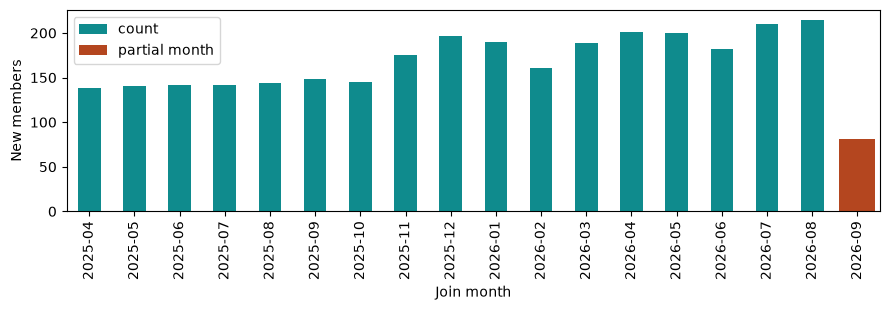


4) กลุ่มที่ต้องระวัง
ต่ำกว่า 18 ปี: 113 คน (3.8%) · ข้อมูลผู้เยาว์ (PDPA) ควรมีความยินยอมจากผู้ปกครอง
gender ไม่ระบุ: 116 คน (3.9%) · เป็นค่าที่ถูกต้อง ไม่ใช่ missing ห้ามเดาเพศแทน


In [7]:
# วางโค้ดที่ AI เขียนให้ที่นี่ แล้วรัน
import math
import matplotlib.pyplot as plt

# 1) เบอร์ซ้ำ: เกิดจากการ mask หรือลูกค้าซ้ำ?
section("1) เบอร์ซ้ำ vs ที่คาดจากการ mask")
prefixes = df["phone"].str[:3].nunique()
space = prefixes * 10_000               # prefix ที่พบ × 4 หลักท้าย
n = len(df)
expected_unique = space * (1 - math.exp(-n / space))
print(f"รูปแบบเบอร์ที่เป็นไปได้หลัง mask: {prefixes} prefix × 10,000 = {space:,}")
print(f"คาดว่าเบอร์ชนกันโดยบังเอิญ ≈ {n - expected_unique:.1f} แถว · พบจริง {n_dup_phone} แถว")
pairs = df[df["phone"].duplicated(keep=False)].sort_values("phone")
same_profile = pairs.duplicated(["phone", "nickname", "gender"], keep=False)
print(f"คู่เบอร์ซ้ำที่ชื่อเล่น+เพศตรงกันด้วย (น่าสงสัยว่าเป็นคนเดียวกัน): {same_profile.sum() // 2} คู่")
print(pairs[same_profile].to_string())

# 2) ชื่อเล่น × เพศ
section("2) ชื่อเล่น × เพศ")
ct = pd.crosstab(df["nickname"], df["gender"])
ct["% หญิง"] = (ct["หญิง"] / ct.sum(axis=1) * 100).round(0)
print(ct.sort_values("% หญิง").to_string())
male_names, female_names = ["สมชาย", "มานพ", "วีระ"], ["สุดา", "รัตนา", "อัญชลี"]
conflict = (df["nickname"].isin(male_names) & (df["gender"] == "หญิง")) | \
           (df["nickname"].isin(female_names) & (df["gender"] == "ชาย"))
n_name_gender_conflict = int(conflict.sum())
print(f"\nชื่อเล่นที่บอกเพศชัด แต่เพศขัดกัน: {n_name_gender_conflict:,} แถว "
      f"จาก {df['nickname'].isin(male_names + female_names).sum():,} แถว")

# 3) สมัครรายเดือน
section("3) จำนวนสมัครรายเดือน")
monthly = df["joined_date"].str[:7].value_counts().sort_index()
print(monthly.to_string())
last_day = df["joined_date"].max()
print(f"วันที่สมัครล่าสุด {last_day} → เดือน {last_day[:7]} มีข้อมูลไม่ครบเดือน อย่านำไปเทียบกับเดือนอื่นตรง ๆ")

ax = monthly.plot.bar(color="#0F8B8D", figsize=(9, 3.2))
ax.bar(len(monthly) - 1, monthly.iloc[-1], color="#B4461F", label="partial month")
ax.set_xlabel("Join month"); ax.set_ylabel("New members"); ax.legend()
plt.tight_layout(); plt.show()
# หมายเหตุ: ใช้ป้ายภาษาอังกฤษ เพราะ matplotlib ใน Colab ไม่มีฟอนต์ไทย

# 4) กลุ่มที่ต้องระวัง
section("4) กลุ่มที่ต้องระวัง")
print(f"ต่ำกว่า 18 ปี: {n_under18:,} คน ({n_under18 / n:.1%}) · ข้อมูลผู้เยาว์ (PDPA) ควรมีความยินยอมจากผู้ปกครอง")
print(f"gender ไม่ระบุ: {n_gender_unknown:,} คน ({n_gender_unknown / n:.1%}) · เป็นค่าที่ถูกต้อง ไม่ใช่ missing ห้ามเดาเพศแทน")

### 📋 สรุปผล Profiling ของ `customers.csv`

| # | ประเด็น | พบ | ประเภท | ระดับ |
|---|---|---|---|---|
| 1 | ค่าว่าง / แถวซ้ำ / ID ซ้ำ / รูปแบบผิด | 0 | รูปแบบ | ✅ ผ่าน |
| 2 | ค่าหมวดหมู่นอกมาตรฐาน (gender, age_group, home_branch_id) | 0 | รูปแบบ | ✅ ผ่าน |
| 3 | ความสัมพันธ์ข้ามตาราง และลำดับเวลา (สมัคร ≥ สาขาเปิด, ซื้อ ≥ สมัคร) | 0 | ความสอดคล้อง | ✅ ผ่าน |
| 4 | เบอร์โทรซ้ำ | 50 แถว | ความหมาย | 🟡 ส่วนใหญ่เกิดจาก mask (คาดไว้ ≈ 49) ไม่ใช่ลูกค้าซ้ำ |
| 5 | ชื่อเล่นกับเพศขัดกัน (เช่น “สมชาย” เป็นหญิง) | 334 จาก 757 แถว (44%) | ความหมาย | 🟡 ชื่อเล่นกับเพศแทบไม่สัมพันธ์กันเลย (ทุกชื่อเป็นหญิง ~47–65%) น่าจะเป็นข้อมูลสังเคราะห์หรือกรอกผิด แต่แก้จากชื่อไม่ได้ |
| 6 | ลูกค้าไม่เคยซื้อ | 493 คน (16.4%) | พฤติกรรม | 🟡 ส่วนใหญ่เพิ่งสมัคร ต้องระวังตอนคำนวณ retention |
| 7 | เดือนสุดท้ายข้อมูลไม่ครบ (ก.ย. 2026) | 81 คน | ช่วงเวลา | 🟡 อย่าเทียบตรง ๆ กับเดือนอื่น |
| 8 | ผู้เยาว์ “ต่ำกว่า 18” | 113 คน | กฎหมาย/จริยธรรม | 🟠 ระวังการทำการตลาด |
| 9 | ยอดขายที่ไม่ผูกกับสมาชิก | ~54% ของแถว | ขอบเขตข้อมูล | 🟡 Dashboard ลูกค้าสะท้อนแค่ครึ่งหนึ่งของยอดขาย |
| 10 | สาขาประจำไม่ตรงกับสาขาที่ซื้อบ่อยสุด | ~5% | ความหมาย | ⚪ ปกติ (ลูกค้าย้ายที่ทำงาน/ที่เรียน) |

**บทเรียน:** ไฟล์นี้ “สะอาด” ในเชิงรูปแบบ แต่ยังมีประเด็นเชิงความหมายที่ส่งผลต่อการวิเคราะห์ ซึ่งต้องใช้ความรู้ธุรกิจตัดสิน ไม่ใช่โค้ด

## ขั้นที่ 5 · ตัดสินใจก่อนลงมือ (5 นาที · คุยกับเพื่อนข้าง ๆ)

ดับเบิลคลิกเซลล์นี้เพื่อกรอกตาราง

| ประเด็น | ทางเลือก | ตัดสินใจ | เหตุผล |
|---|---|---|---|
| เบอร์โทรซ้ำ 50 แถว | รวมเป็นคนเดียว / เก็บแยก / ติด flag | | |
| ชื่อเล่นกับเพศขัดกัน | แก้เพศตามชื่อ / เก็บตามที่ลูกค้ากรอก | | |
| gender = ไม่ระบุ | เดาจากชื่อ / เก็บเป็นกลุ่มแยก / ตัดออก | | |
| ลูกค้าไม่เคยซื้อ | ลบ / เก็บ / แยกเป็นกลุ่ม “ยังไม่ active” | | |
| เดือน ก.ย. 2026 ไม่ครบเดือน | ตัดออกจากกราฟ / แสดงพร้อมหมายเหตุ / คิดเป็นอัตราต่อวัน | | |
| ลูกค้าต่ำกว่า 18 ปี | เก็บ / ตัดออกจากแคมเปญการตลาด / ขอ consent | | |

> ข้อมูลเพิ่มเติมจากร้าน (ผู้สอนเฉลยเมื่อมีคนถาม): ระบบสมาชิก **ใช้ customer_id เป็นตัวตน ไม่ใช่เบอร์โทร** และไฟล์นี้ mask เบอร์ไว้ตามนโยบาย PDPA · แบบฟอร์มสมัคร **ให้ลูกค้าเลือกเพศเอง** · ข้อมูลถูกดึงเมื่อ **14 ก.ย. 2026**

## ขั้นที่ 6 · Export รายงาน Profiling
`customer_profile.csv` คือภาพรวมรายคอลัมน์ ส่วน `customer_issues.csv` คือรายการประเด็นที่พบพร้อมตัวเลข ให้แนบไว้ใน repo คู่กับ `cleaning_log.csv` ของ Lab 2.1

In [8]:
issues = pd.DataFrame([
    ("แถวซ้ำทุกคอลัมน์", n_dup, "รูปแบบ", "ผ่าน"),
    ("customer_id ซ้ำ", n_dup_id, "รูปแบบ", "ผ่าน"),
    ("ช่องว่าง (ทุกคอลัมน์)", n_blank, "รูปแบบ", "ผ่าน"),
    ("customer_id รูปแบบผิด", n_bad_id, "รูปแบบ", "ผ่าน"),
    ("joined_date รูปแบบผิด/ไม่มีจริง", n_bad_date, "รูปแบบ", "ผ่าน"),
    ("phone รูปแบบผิด", n_bad_phone, "รูปแบบ", "ผ่าน"),
    ("customer_id ใน sales ที่ไม่มีใน customers", n_orphan_sales, "ข้ามตาราง", "ผ่าน"),
    ("home_branch_id ที่ไม่มีใน branches", n_orphan_branch, "ข้ามตาราง", "ผ่าน"),
    ("สมัครก่อนสาขาประจำเปิด", n_before_open, "ลำดับเวลา", "ผ่าน"),
    ("ซื้อครั้งแรกก่อนสมัคร", n_buy_before_join, "ลำดับเวลา", "ผ่าน"),
    ("phone ซ้ำกับลูกค้าคนอื่น", n_dup_phone, "ความหมาย", "เฝ้าระวัง: สอดคล้องกับการชนจาก mask"),
    ("ชื่อเล่นที่บอกเพศชัด แต่เพศขัดกัน", n_name_gender_conflict, "ความหมาย", "เฝ้าระวัง: เก็บตามที่ลูกค้ากรอก"),
    ("gender = ไม่ระบุ", n_gender_unknown, "ความหมาย", "ค่าถูกต้อง แสดงเป็นกลุ่มแยก"),
    ("age_group = ต่ำกว่า 18", n_under18, "PDPA", "ระวังการตลาด"),
    ("ลูกค้าไม่เคยซื้อ", n_never_bought, "พฤติกรรม", "แยกกลุ่มยังไม่ active"),
    ("สมัครเดือนสุดท้าย (ไม่ครบเดือน)", int(monthly.iloc[-1]), "ช่วงเวลา", "แสดงพร้อมหมายเหตุ"),
], columns=["ประเด็น", "จำนวน", "ประเภท", "สถานะ/ข้อเสนอ"])

profile.to_csv("customer_profile.csv", encoding="utf-8-sig")
issues.to_csv("customer_issues.csv", index=False, encoding="utf-8-sig")
print("บันทึก customer_profile.csv และ customer_issues.csv แล้ว")
display(issues)

try:
    from google.colab import files
    files.download("customer_profile.csv")
    files.download("customer_issues.csv")
except ImportError:
    pass

บันทึก customer_profile.csv และ customer_issues.csv แล้ว


,ประเด็น,จำนวน,ประเภท,สถานะ/ข้อเสนอ
0,แถวซ้ำทุกคอลัมน์,0,รูปแบบ,ผ่าน
1,customer_id ซ้ำ,0,รูปแบบ,ผ่าน
2,ช่องว่าง (ทุกคอลัมน์),0,รูปแบบ,ผ่าน
3,customer_id รูปแบบผิด,0,รูปแบบ,ผ่าน
4,joined_date รูปแบบผิด/ไม่มีจริง,0,รูปแบบ,ผ่าน
5,phone รูปแบบผิด,0,รูปแบบ,ผ่าน
6,customer_id ใน sales ที่ไม่มีใน customers,0,ข้ามตาราง,ผ่าน
7,home_branch_id ที่ไม่มีใน branches,0,ข้ามตาราง,ผ่าน
8,สมัครก่อนสาขาประจำเปิด,0,ลำดับเวลา,ผ่าน
9,ซื้อครั้งแรกก่อนสมัคร,0,ลำดับเวลา,ผ่าน


**คำถามชวนคิด:** ถ้าจะทำ KPI “จำนวนลูกค้า active ต่อเดือน” บน Dashboard คุณจะนิยามคำว่า active อย่างไร และจากผล profiling ข้างบน มีกับดักอะไรบ้างที่ต้องเขียนหมายเหตุไว้ใต้กราฟ

---
### 🚀 เสร็จเร็ว? ลองต่อ
- ให้ AI เขียนฟังก์ชัน `profile_table(df, rules)` ที่ใช้ได้ทั้ง `customers.csv`, `products.csv`, `branches.csv` โดยรับกฎเป็น dict (regex, ค่ามาตรฐาน)
- ลอง profile `products.csv` แล้วเทียบ `price` กับ `unit_price` ใน `sales.csv` ว่ามีสินค้าที่ขายราคาไม่ตรงกับป้ายไหม
- คำนวณ RFM (Recency, Frequency, Monetary) ของลูกค้าแต่ละคน แล้วดูว่ากลุ่มไหนควรได้โปรโมชันก่อน